# 02 — Environment Rollout Diagnostics (Plots)

Goal: run controlled rollouts and plot:
- SoC trajectory (bounds + dynamics)
- P_req vs P_applied (clipping visibility)
- planned vs applied power
- DA vs ID prices
- DA availability step function
- reward decomposition (profit_norm vs carbon_penalty_norm)

# 0. Imports + Env Factory

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from battery_env import BatteryEnv
import env_config

pd.set_option("display.max_columns", 200)

def make_env(seed=123, publish_hour=12, episode_days=5, randomize_init_soc=True):
    env = BatteryEnv(
        config=env_config,
        publish_hour=publish_hour,
        episode_days=episode_days,
        randomize_init_soc=randomize_init_soc,
        seed=seed,
    )
    return env

env = make_env(seed=123, episode_days=5, randomize_init_soc=True)
obs, info = env.reset(seed=123)
print("obs_len:", len(obs), "info:", info)

S_profit (DA+ID, £): 62.9324448499999
S_carbon (monetised, £): 4.76261683125
obs_len: 103 info: {'start_day': '2023-03-06', 'publish_hour': 12, 'episode_days': 5, 'init_soc': 0.5729407452992574}


## 1. Rollout runner → DataFrame

In [2]:
def run_rollout(env, n_steps, policy_fn, seed=123):
    obs, info0 = env.reset(seed=seed)
    rows = []
    for t in range(n_steps):
        action = policy_fn(env, obs, t)
        obs, rew, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)

        row = {"t": t, "reward": float(rew), "done": done}
        for k, v in info.items():
            row[k] = v
        rows.append(row)

        if done:
            break

    df = pd.DataFrame(rows)
    # ensure timestamps are parsed for plotting convenience
    for col in ["delivery_ts", "decision_ts"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

## 2. Policies

In [3]:
def policy_random(env, obs, t, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    a = env.action_space.sample()
    return np.array(a, dtype=np.int64)

def policy_do_nothing(env, obs, t):
    mid = env.n_power_levels // 2
    return np.array([mid, mid, 0], dtype=np.int64)

def policy_force_extremes(env, obs, t):
    # alternate charge/discharge to trigger clipping and SoC movement
    charge_idx = 0
    discharge_idx = env.n_power_levels - 1
    plan_idx = env.n_power_levels // 2
    plan_slot = (t % 48)
    dispatch = charge_idx if (t % 2 == 0) else discharge_idx
    return np.array([dispatch, plan_idx, plan_slot], dtype=np.int64)

## 3. Run 3 Rollouts

In [4]:
rng = np.random.default_rng(123)

df_rand = run_rollout(env, n_steps=300, policy_fn=lambda e,o,t: policy_random(e,o,t,rng=rng), seed=123)
df_zero = run_rollout(env, n_steps=300, policy_fn=policy_do_nothing, seed=123)
df_ext  = run_rollout(env, n_steps=300, policy_fn=policy_force_extremes, seed=123)

print("rand steps:", len(df_rand), "zero steps:", len(df_zero), "ext steps:", len(df_ext))
df_rand.head()

rand steps: 240 zero steps: 240 ext steps: 240


,t,reward,done,trade_date,delivery_date,tau,decision_ts,delivery_ts,trade_ts,dispatch_idx_exec,dispatch_idx_agent,plan_idx_agent,planned_idx_today,plan_slot_agent,tomorrow_plan_value_written,mef_now,carbon_price_now,idx,P_req_MW,P_planned_MW,P_dev_MW,P_applied_MW,delta_soc,id_price_now,da_price_now,ci_now,Planned_Profit,Intraday_Profit,profit_norm,carbon_penalty_norm,da_available,days_done,soc
0,0,3.854182e-01,False,2023-03-05 00:00:00,2023-03-06 00:00:00,1,2023-03-06 00:00:00,2023-03-06 00:00:00,2023-03-05 00:00:00,8,8,4,-1,47,-999,370.0,75.650002,20590,0.11181,0.0,1.118100e-01,1.118100e-01,-0.147015,112.849998,124.800003,256.0,0.0,6.308879e+00,9.991396e-02,-3.172269e-01,False,0,0.425926
1,1,0.000000e+00,False,2023-03-05 00:00:00,2023-03-06 00:00:00,2,2023-03-06 00:30:00,2023-03-06 00:30:00,2023-03-05 00:30:00,5,5,10,-1,31,-999,370.0,75.650002,20591,0.00000,0.0,0.000000e+00,0.000000e+00,0.000000,117.550003,143.199997,256.0,0.0,0.000000e+00,0.000000e+00,-0.000000e+00,False,0,0.425926
2,2,3.967586e-01,False,2023-03-05 00:00:00,2023-03-06 00:00:00,3,2023-03-06 01:00:00,2023-03-06 01:00:00,2023-03-05 01:00:00,8,8,9,-1,41,-999,370.0,75.650002,20592,0.11181,0.0,1.118100e-01,1.118100e-01,-0.147429,125.760002,133.300003,257.0,0.0,7.030613e+00,1.112544e-01,-3.172269e-01,False,0,0.278497
3,3,4.720757e-01,False,2023-03-05 00:00:00,2023-03-06 00:00:00,4,2023-03-06 01:30:00,2023-03-06 01:30:00,2023-03-05 01:30:00,10,10,2,-1,27,-999,370.0,75.650002,20593,0.18635,0.0,1.345134e-01,1.345134e-01,-0.178497,125.919998,120.000000,256.0,0.0,8.468965e+00,1.337658e-01,-3.758998e-01,False,0,0.100000
4,4,1.535126e-16,False,2023-03-05 00:00:00,2023-03-06 00:00:00,5,2023-03-06 02:00:00,2023-03-06 02:00:00,2023-03-05 02:00:00,7,7,9,-1,40,-999,370.0,75.650002,20594,0.07454,0.0,4.144667e-17,4.144667e-17,0.000000,133.309998,121.599998,251.0,0.0,2.762628e-15,4.389830e-17,-1.217936e-16,False,0,0.100000


## 4. Helper: clipping indicator + basic metrics

In [5]:
def add_clipping_flags(df):
    df = df.copy()
    if "P_req_MW" in df.columns and "P_applied_MW" in df.columns:
        df["clipped"] = np.abs(df["P_req_MW"] - df["P_applied_MW"]) > 1e-6
    else:
        df["clipped"] = False
    return df

def metrics(df):
    out = {}
    if "soc" in df.columns:
        out["soc_min"] = float(np.min(df["soc"]))
        out["soc_max"] = float(np.max(df["soc"]))
    if "clipped" in df.columns:
        out["clip_rate"] = float(np.mean(df["clipped"]))
    out["mean_reward"] = float(np.mean(df["reward"])) if len(df) else np.nan
    return out

df_rand = add_clipping_flags(df_rand)
df_zero = add_clipping_flags(df_zero)
df_ext  = add_clipping_flags(df_ext)

print("Random:", metrics(df_rand))
print("Do-nothing:", metrics(df_zero))
print("Extremes:", metrics(df_ext))

Random: {'soc_min': 0.09999999999999934, 'soc_max': 0.9000000000000007, 'clip_rate': 0.19583333333333333, 'mean_reward': 0.04200339347254354}
Do-nothing: {'soc_min': 0.5729407452992574, 'soc_max': 0.5729407452992574, 'clip_rate': 0.0, 'mean_reward': 0.0}
Extremes: {'soc_min': 0.09999999999999953, 'soc_max': 0.8092611446495057, 'clip_rate': 0.24583333333333332, 'mean_reward': 0.09426463280604834}


## 5. Plot 1: SoC over time

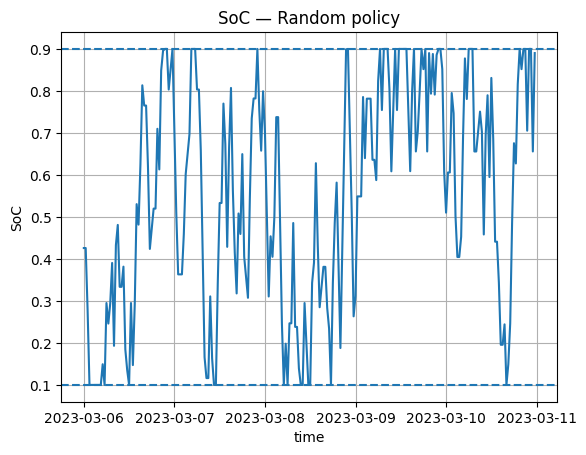

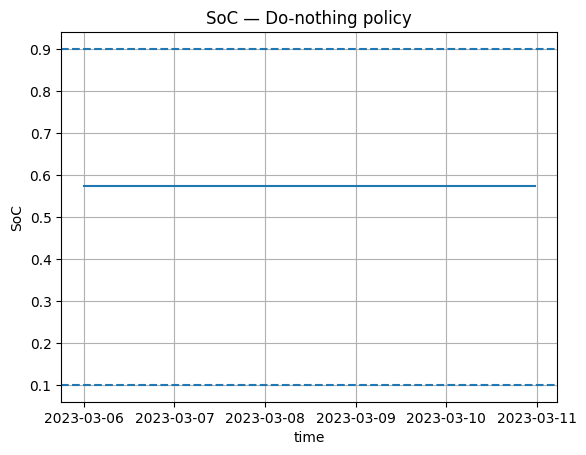

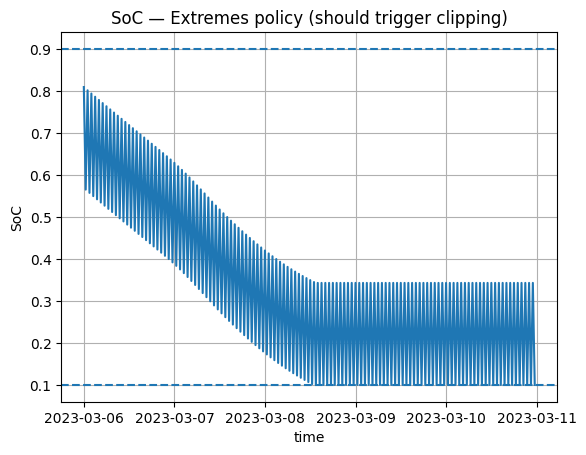

In [14]:
def plot_soc(df, title):
    plt.figure()
    if "delivery_ts" in df.columns:
        x = df["delivery_ts"]
    else:
        x = df["t"]
    plt.plot(x, df["soc"])
    plt.axhline(env.SoC_min, linestyle="--")
    plt.axhline(env.SoC_max, linestyle="--")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("SoC")
    plt.grid(True)
    plt.show()

plot_soc(df_rand, "SoC — Random policy")
plot_soc(df_zero, "SoC — Do-nothing policy")
plot_soc(df_ext,  "SoC — Extremes policy (should trigger clipping)")

## 6. Plot 2: Power request vs applied (clipping visibility)

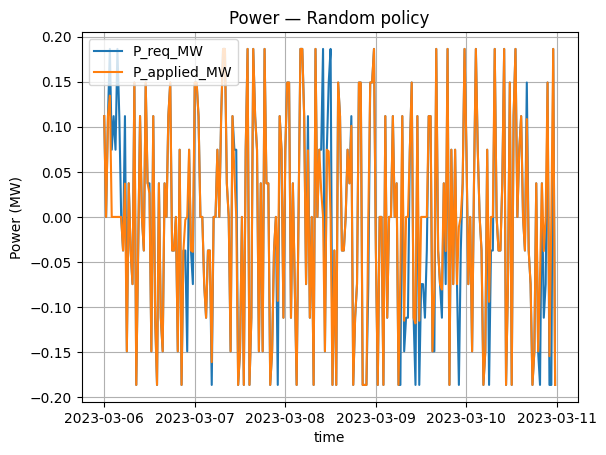

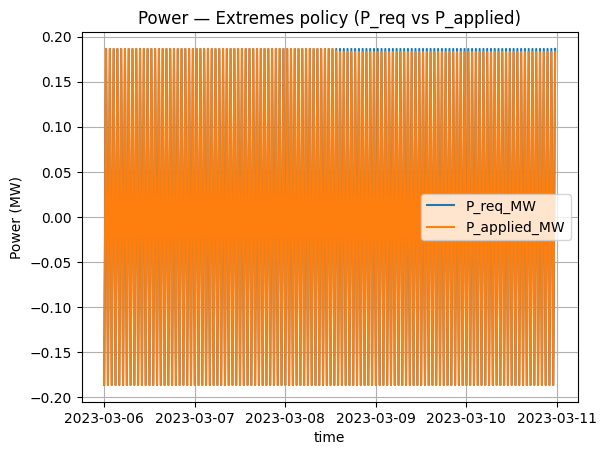

In [15]:
def plot_power_req_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_req_MW" in df.columns:
        plt.plot(x, df["P_req_MW"], label="P_req_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_power_req_vs_applied(df_rand, "Power — Random policy")
plot_power_req_vs_applied(df_ext,  "Power — Extremes policy (P_req vs P_applied)")

## 7. Plot 3: Planned vs applied power

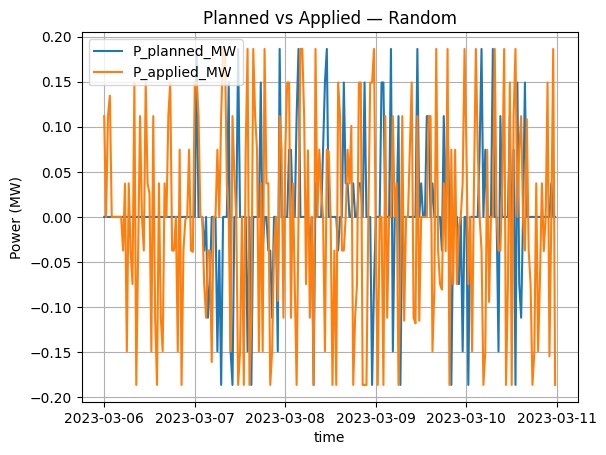

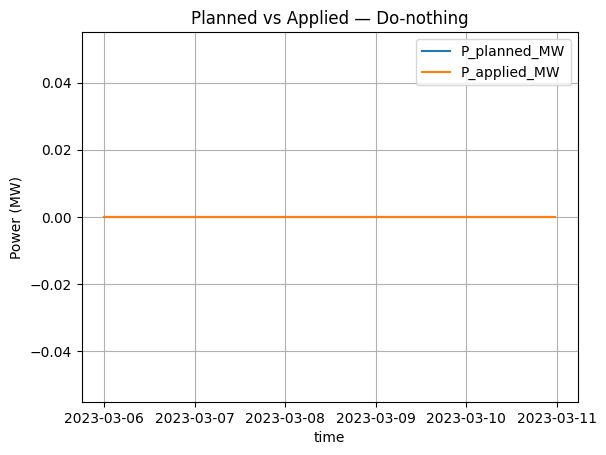

,delivery_ts,tau,P_planned_MW,P_applied_MW,P_dev_MW,soc,Planned_Profit,Intraday_Profit,carbon_penalty_norm,da_available,reward
0,2023-03-06 00:00:00,1,0.0,1.118100e-01,1.118100e-01,0.425926,0.0,6.308879e+00,-3.172269e-01,False,3.854182e-01
1,2023-03-06 00:30:00,2,0.0,0.000000e+00,0.000000e+00,0.425926,0.0,0.000000e+00,-0.000000e+00,False,0.000000e+00
2,2023-03-06 01:00:00,3,0.0,1.118100e-01,1.118100e-01,0.278497,0.0,7.030613e+00,-3.172269e-01,False,3.967586e-01
3,2023-03-06 01:30:00,4,0.0,1.345134e-01,1.345134e-01,0.100000,0.0,8.468965e+00,-3.758998e-01,False,4.720757e-01
4,2023-03-06 02:00:00,5,0.0,4.144667e-17,4.144667e-17,0.100000,0.0,2.762628e-15,-1.217936e-16,False,1.535126e-16
5,2023-03-06 02:30:00,6,0.0,4.144667e-17,4.144667e-17,0.100000,0.0,2.522651e-15,-1.217936e-16,False,1.496994e-16
6,2023-03-06 03:00:00,7,0.0,4.144667e-17,4.144667e-17,0.100000,0.0,2.352720e-15,-1.217936e-16,False,1.469991e-16
7,2023-03-06 03:30:00,8,0.0,4.144667e-17,4.144667e-17,0.100000,0.0,2.306093e-15,-1.217936e-16,False,1.462582e-16
8,2023-03-06 04:00:00,9,0.0,4.144667e-17,4.144667e-17,0.100000,0.0,2.403078e-15,-1.217936e-16,False,1.477993e-16
9,2023-03-06 04:30:00,10,0.0,0.000000e+00,0.000000e+00,0.100000,0.0,0.000000e+00,-0.000000e+00,False,0.000000e+00


In [16]:
def plot_planned_vs_applied(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "P_planned_MW" in df.columns:
        plt.plot(x, df["P_planned_MW"], label="P_planned_MW")
    if "P_applied_MW" in df.columns:
        plt.plot(x, df["P_applied_MW"], label="P_applied_MW")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Power (MW)")
    plt.grid(True)
    plt.legend()
    plt.show()

def planned_vs_applied_table(df, n):
    cols = [
        "delivery_ts",
        "tau",
        "P_planned_MW",
        "P_applied_MW",
        "P_dev_MW",
        "soc",
        "Planned_Profit",
        "Intraday_Profit",
        "carbon_penalty_norm",
        "da_available",
        "reward",
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols].head(n)



plot_planned_vs_applied(df_rand, "Planned vs Applied — Random")
plot_planned_vs_applied(df_zero, "Planned vs Applied — Do-nothing")
planned_vs_applied_table(df_rand, n=25)

## 8.Plot 4: Prices (DA vs ID) + carbon intensity

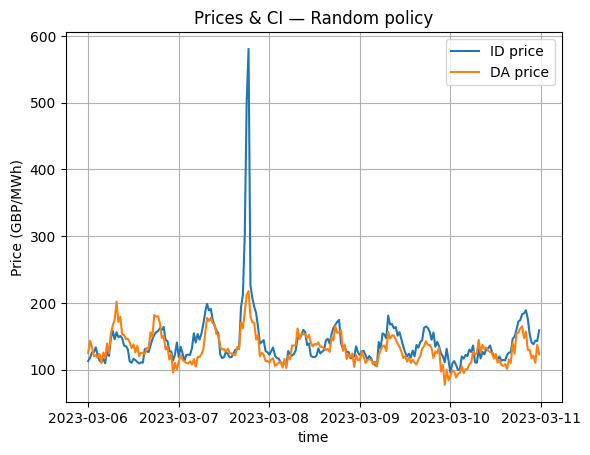

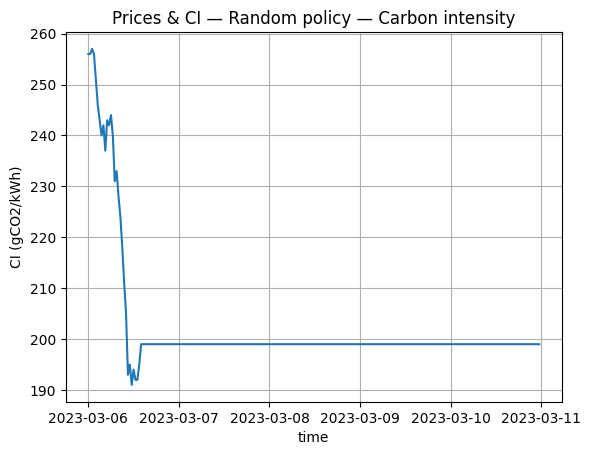

       t         delivery_ts  tau  ci_now
180  180 2023-03-09 18:00:00   37   199.0
181  181 2023-03-09 18:30:00   38   199.0
182  182 2023-03-09 19:00:00   39   199.0
183  183 2023-03-09 19:30:00   40   199.0
184  184 2023-03-09 20:00:00   41   199.0
185  185 2023-03-09 20:30:00   42   199.0
186  186 2023-03-09 21:00:00   43   199.0
187  187 2023-03-09 21:30:00   44   199.0
188  188 2023-03-09 22:00:00   45   199.0
189  189 2023-03-09 22:30:00   46   199.0
190  190 2023-03-09 23:00:00   47   199.0
191  191 2023-03-09 23:30:00   48   199.0
192  192 2023-03-10 00:00:00    1   199.0
193  193 2023-03-10 00:30:00    2   199.0
194  194 2023-03-10 01:00:00    3   199.0
195  195 2023-03-10 01:30:00    4   199.0
196  196 2023-03-10 02:00:00    5   199.0
197  197 2023-03-10 02:30:00    6   199.0
198  198 2023-03-10 03:00:00    7   199.0
199  199 2023-03-10 03:30:00    8   199.0
200  200 2023-03-10 04:00:00    9   199.0
201  201 2023-03-10 04:30:00   10   199.0
202  202 2023-03-10 05:00:00   11 

In [ ]:
def plot_prices_and_ci(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "id_price_now" in df.columns:
        plt.plot(x, df["id_price_now"], label="ID price")
    if "da_price_now" in df.columns:
        plt.plot(x, df["da_price_now"], label="DA price")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Price (GBP/MWh)")
    plt.grid(True)
    plt.legend()
    plt.show()

    if "ci_now" in df.columns:
        plt.figure()
        plt.plot(x, df["ci_now"])
        plt.title(title + " — Carbon intensity")
        plt.xlabel("time")
        plt.ylabel("CI (gCO2/kWh)")
        plt.grid(True)
        plt.show()

plot_prices_and_ci(df_rand, "Prices & CI — Random policy")
print(df_rand["ci_now"].nunique(), df_rand["delivery_ts"].nunique())
print(df_rand[["t","delivery_ts","tau","ci_now"]].tail(60))

## 9.  Plot 5: DA availability indicator

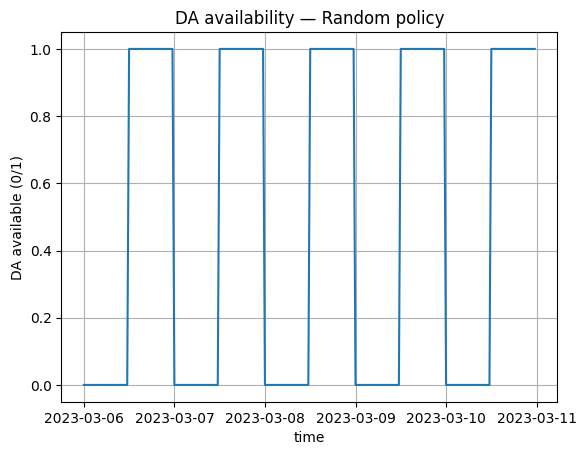

In [18]:
def plot_da_availability(df, title):
    if "da_available" not in df.columns:
        print("da_available not in df")
        return
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    plt.plot(x, df["da_available"].astype(int))
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("DA available (0/1)")
    plt.grid(True)
    plt.show()

plot_da_availability(df_rand, "DA availability — Random policy")

## 10. Plot 6: Reward decomposition (profit_norm vs carbon_penalty_norm vs reward)

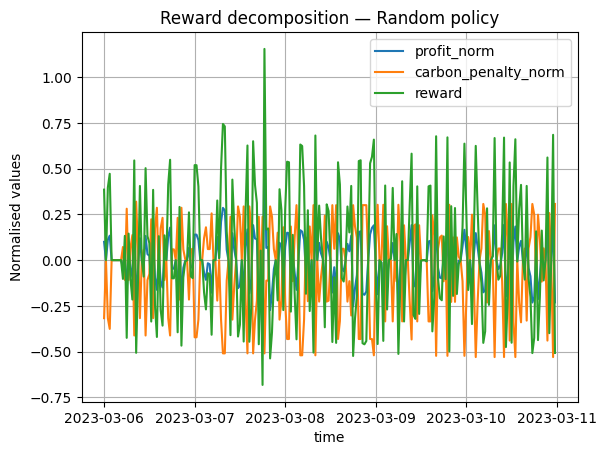

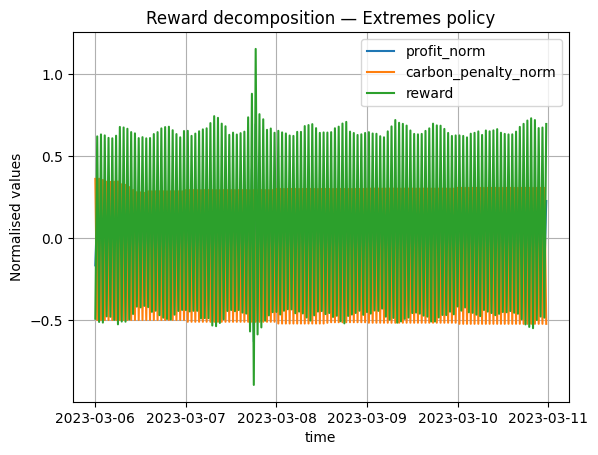

In [19]:
def plot_reward_decomposition(df, title):
    plt.figure()
    x = df["delivery_ts"] if "delivery_ts" in df.columns else df["t"]
    if "profit_norm" in df.columns:
        plt.plot(x, df["profit_norm"], label="profit_norm")
    if "carbon_penalty_norm" in df.columns:
        plt.plot(x, df["carbon_penalty_norm"], label="carbon_penalty_norm")
    plt.plot(x, df["reward"], label="reward")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("Normalised values")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_reward_decomposition(df_rand, "Reward decomposition — Random policy")
plot_reward_decomposition(df_ext,  "Reward decomposition — Extremes policy")

## 11. Plot 7: clipping histogram + applied power distribution

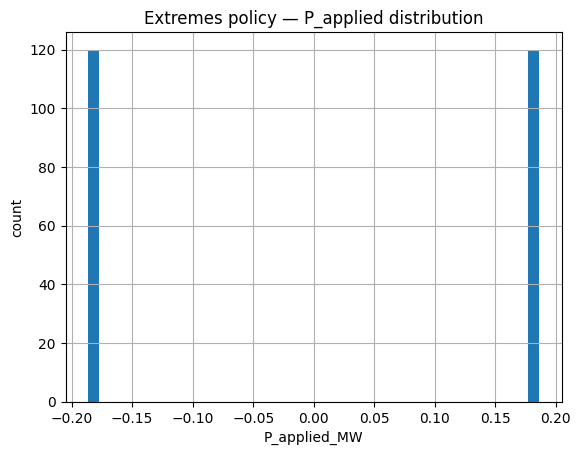

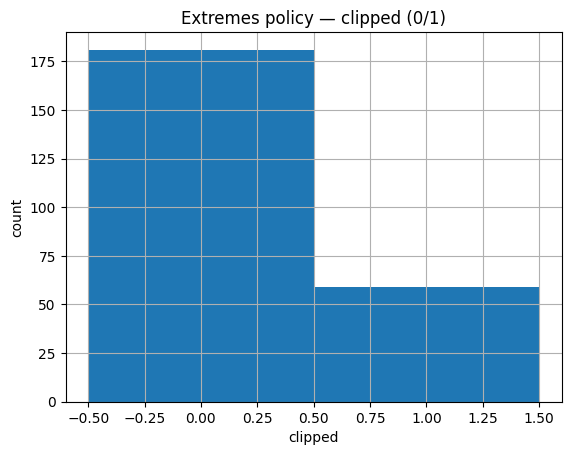

In [20]:
def plot_distributions(df, title):
    plt.figure()
    if "P_applied_MW" in df.columns:
        plt.hist(df["P_applied_MW"].dropna().to_numpy(), bins=40)
        plt.title(title + " — P_applied distribution")
        plt.xlabel("P_applied_MW")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

    if "clipped" in df.columns:
        plt.figure()
        plt.hist(df["clipped"].astype(int).to_numpy(), bins=[-0.5,0.5,1.5])
        plt.title(title + " — clipped (0/1)")
        plt.xlabel("clipped")
        plt.ylabel("count")
        plt.grid(True)
        plt.show()

plot_distributions(df_ext, "Extremes policy")

# Summary

In [13]:
summary = pd.DataFrame([
    {"policy": "random", **metrics(df_rand)},
    {"policy": "do_nothing", **metrics(df_zero)},
    {"policy": "extremes", **metrics(df_ext)},
])
summary

,policy,soc_min,soc_max,clip_rate,mean_reward
0,random,0.100000,0.900000,0.195833,0.042003
1,do_nothing,0.572941,0.572941,0.000000,0.000000
2,extremes,0.100000,0.809261,0.245833,0.094265
